# Task 3 -- Forecasting Models (SARIMA / LSTM / GRU)

One-step-ahead forecasting of the 16-22 December test week for the three target areas. The test week is held out from all training and from scaler calibration.

In [1]:
# --- Project setup: make the `src` package importable from anywhere ---
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))
print(f"Project root: {_root}")

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


Project root: C:\Users\josue\Music\ml_tech_I\formative_1


In [2]:
from src.data_loading import (load_traffic_matrix, resolve_target_areas,
                              get_area_series)
from src.preprocessing import prepare_forecasting_data
from src.models import SarimaForecaster, NeuralForecaster
from src.metrics import evaluate, metrics_table
from src.utils import set_global_seed
set_global_seed()
matrix = load_traffic_matrix()
areas = resolve_target_areas(matrix)
areas

{'highest': 5161, 'fixed_1': 4159, 'fixed_2': 4556}

## 3.I/3.VI -- Model & input representation
* **SARIMA** -- classical statistical model; consumes the raw series, fitted once then rolled one-step-ahead with Kalman updates.
* **LSTM / GRU** -- recurrent networks; input is a window of the `lookback` most recent scaled values, shape `(lookback, 1)`; the scaler is fitted on the training span only.

We first demonstrate on the highest-traffic area, then loop over all three.

In [3]:
ref_id = areas['highest']
series = get_area_series(matrix, ref_id)
data = prepare_forecasting_data(series)
print('input shape (lookback, features):', data.input_shape)
print('train/val/test windows:', data.meta)

input shape (lookback, features): (12, 1)
train/val/test windows: {'scaler_kind': 'minmax', 'val_fraction': 0.15, 'n_train': 6599, 'n_val': 1165, 'n_test': 1008}


### Train the three models on the reference area

In [4]:
sarima = SarimaForecaster()
res_sarima = sarima.fit_predict(series)
res_sarima

[timer] SARIMA fit (area 5161): 1.473 s
[timer] SARIMA rolling forecast (area 5161): 0.032 s


ForecastResult(model=SARIMA, area=5161, n_test=1008, train=1.47s, predict=0.032s)

In [5]:
lstm = NeuralForecaster(cell='LSTM', verbose=0)
res_lstm = lstm.fit_predict(data)
print(lstm.summary())
res_lstm

[timer] LSTM fit (area 5161): 12.981 s


[timer] LSTM predict (area 5161): 0.314 s


Model: "LSTM_forecaster"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,885 (198.77 KB)
 Trainable params: 16,961 (66.25 KB)
 Non-trainable params: 0 (0.00 B)
 Optimizer params: 33,924 (132.52 KB)



ForecastResult(model=LSTM, area=5161, n_test=1008, train=12.98s, predict=0.314s)

In [6]:
gru = NeuralForecaster(cell='GRU', verbose=0)
res_gru = gru.fit_predict(data)
res_gru

[timer] GRU fit (area 5161): 13.735 s
[timer] GRU predict (area 5161): 0.203 s


ForecastResult(model=GRU, area=5161, n_test=1008, train=13.74s, predict=0.203s)

### Metrics and forecast plot for the reference area

,MAE,RMSE,MAPE,sMAPE,n,n_near_zero
model,,,,,,
SARIMA,101.246251,146.462043,11.221249,11.155737,1008,0
LSTM,87.086109,129.515472,9.934707,9.472886,1008,0
GRU,86.743866,130.885390,8.881942,8.683120,1008,0


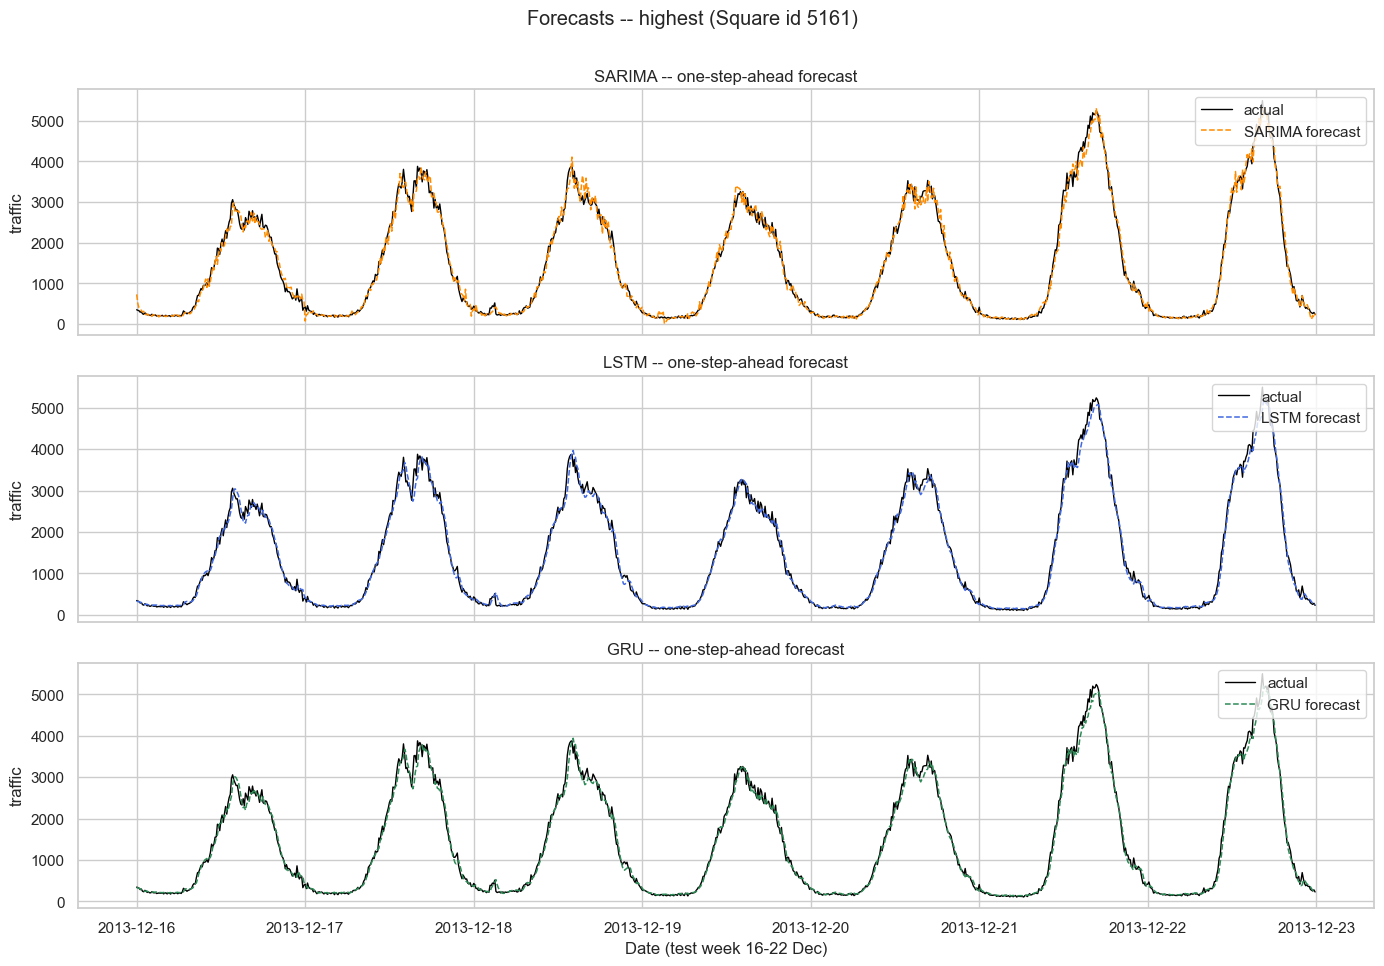

In [7]:
results = [res_sarima, res_lstm, res_gru]
table = metrics_table([evaluate(r.y_true, r.y_pred, r.model_name)
                       for r in results])
display(table)
from src.viz import plot_forecasts_for_area
plot_forecasts_for_area('highest', ref_id, results)

## 3.II/3.III -- Full run: all models on all three areas
Produces the nine prediction plots and three metric tables. For speed in the notebook set `verbose=0`; the full batch run is `python scripts/run_task3.py`.

[timer] SARIMA fit (area 5161): 1.487 s
[timer] SARIMA rolling forecast (area 5161): 0.031 s


[timer] LSTM fit (area 5161): 12.888 s
[timer] LSTM predict (area 5161): 0.175 s


[timer] GRU fit (area 5161): 13.941 s
[timer] GRU predict (area 5161): 0.203 s

=== highest (area 5161) ===


,MAE,RMSE,MAPE,sMAPE,n,n_near_zero
model,,,,,,
SARIMA,101.246251,146.462043,11.221249,11.155737,1008,0
LSTM,87.086109,129.515472,9.934707,9.472886,1008,0
GRU,86.743866,130.885390,8.881942,8.683120,1008,0


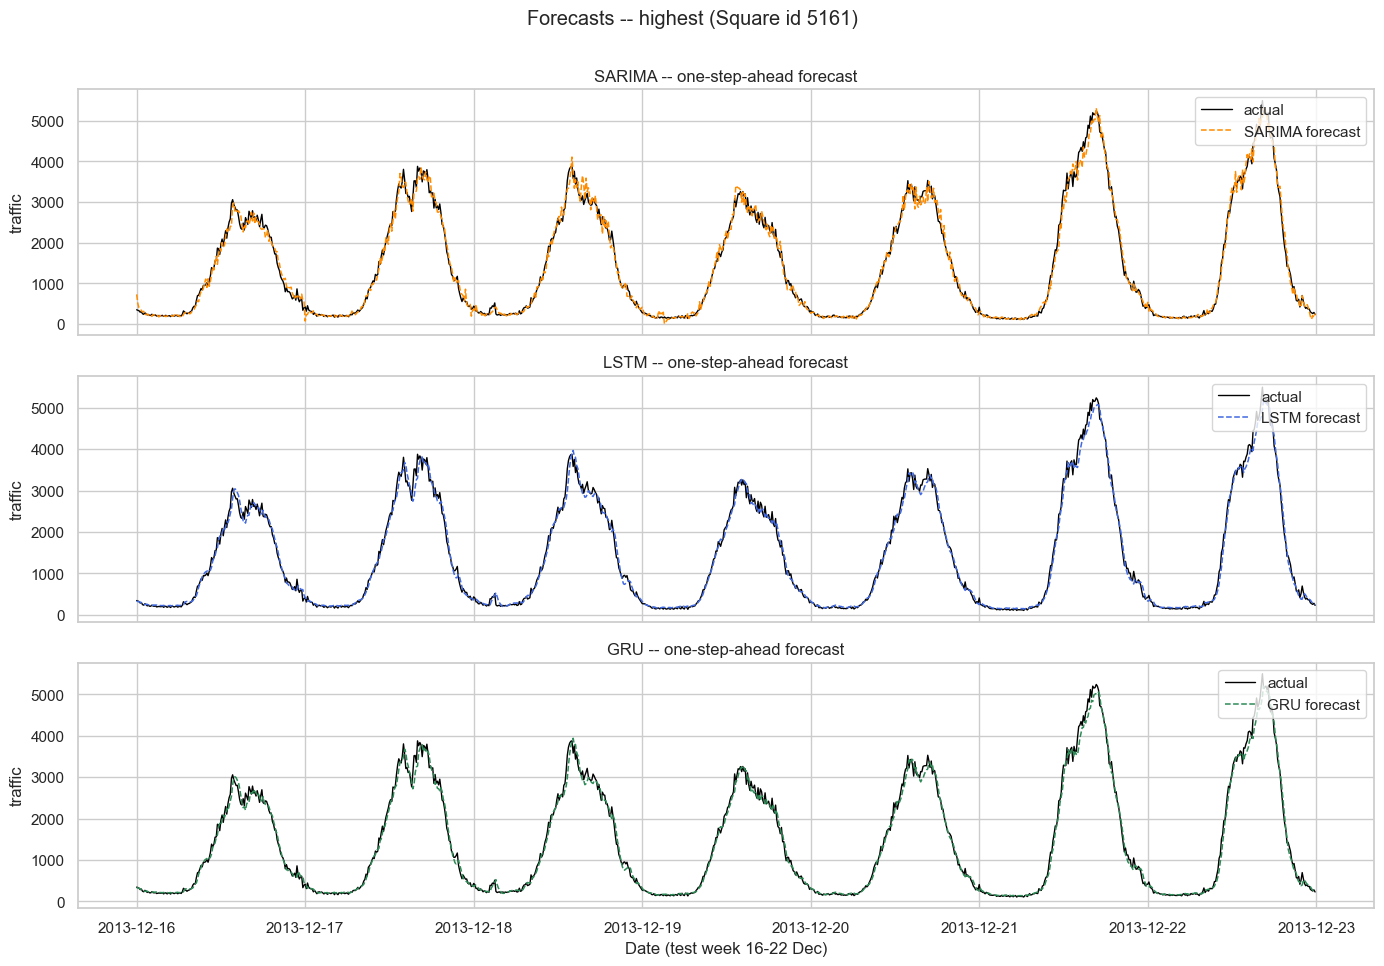

[timer] SARIMA fit (area 4159): 1.548 s
[timer] SARIMA rolling forecast (area 4159): 0.030 s


[timer] LSTM fit (area 4159): 7.053 s
[timer] LSTM predict (area 4159): 0.182 s


[timer] GRU fit (area 4159): 5.082 s
[timer] GRU predict (area 4159): 0.192 s

=== fixed_1 (area 4159) ===


,MAE,RMSE,MAPE,sMAPE,n,n_near_zero
model,,,,,,
SARIMA,19.406848,26.020085,8.761717,8.695878,1008,0
LSTM,16.031178,21.334634,7.239743,7.058923,1008,0
GRU,16.320242,21.410355,7.523307,7.300548,1008,0


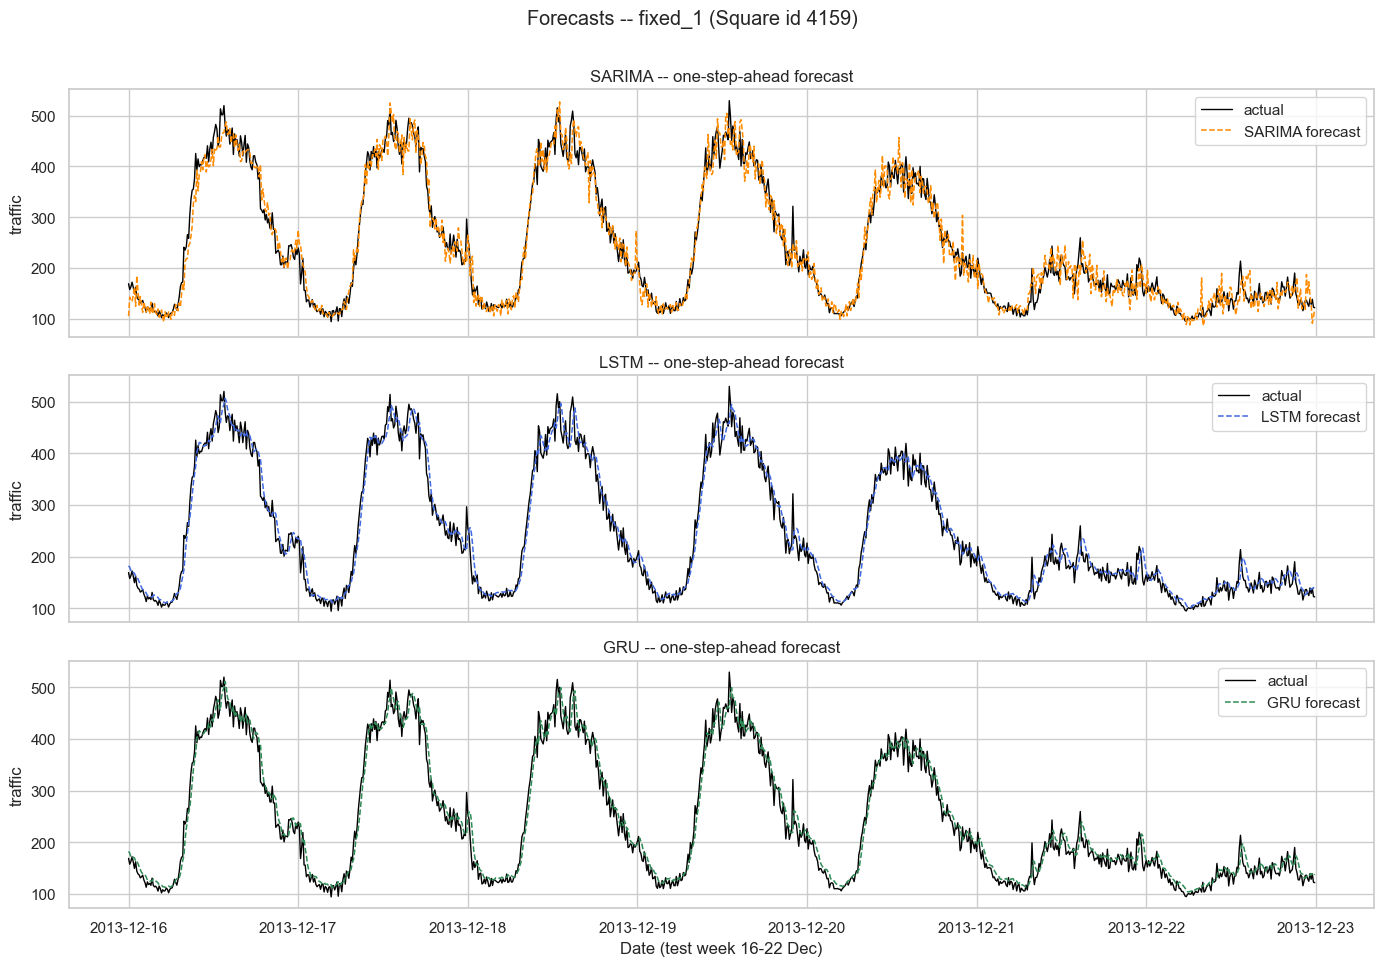

[timer] SARIMA fit (area 4556): 1.283 s
[timer] SARIMA rolling forecast (area 4556): 0.031 s


[timer] LSTM fit (area 4556): 8.609 s
[timer] LSTM predict (area 4556): 0.186 s


[timer] GRU fit (area 4556): 5.215 s
[timer] GRU predict (area 4556): 0.201 s

=== fixed_2 (area 4556) ===


,MAE,RMSE,MAPE,sMAPE,n,n_near_zero
model,,,,,,
SARIMA,34.233106,46.389526,7.721639,7.682502,1008,0
LSTM,27.911319,37.028834,6.489963,6.415079,1008,0
GRU,28.116046,37.037480,6.626124,6.478154,1008,0


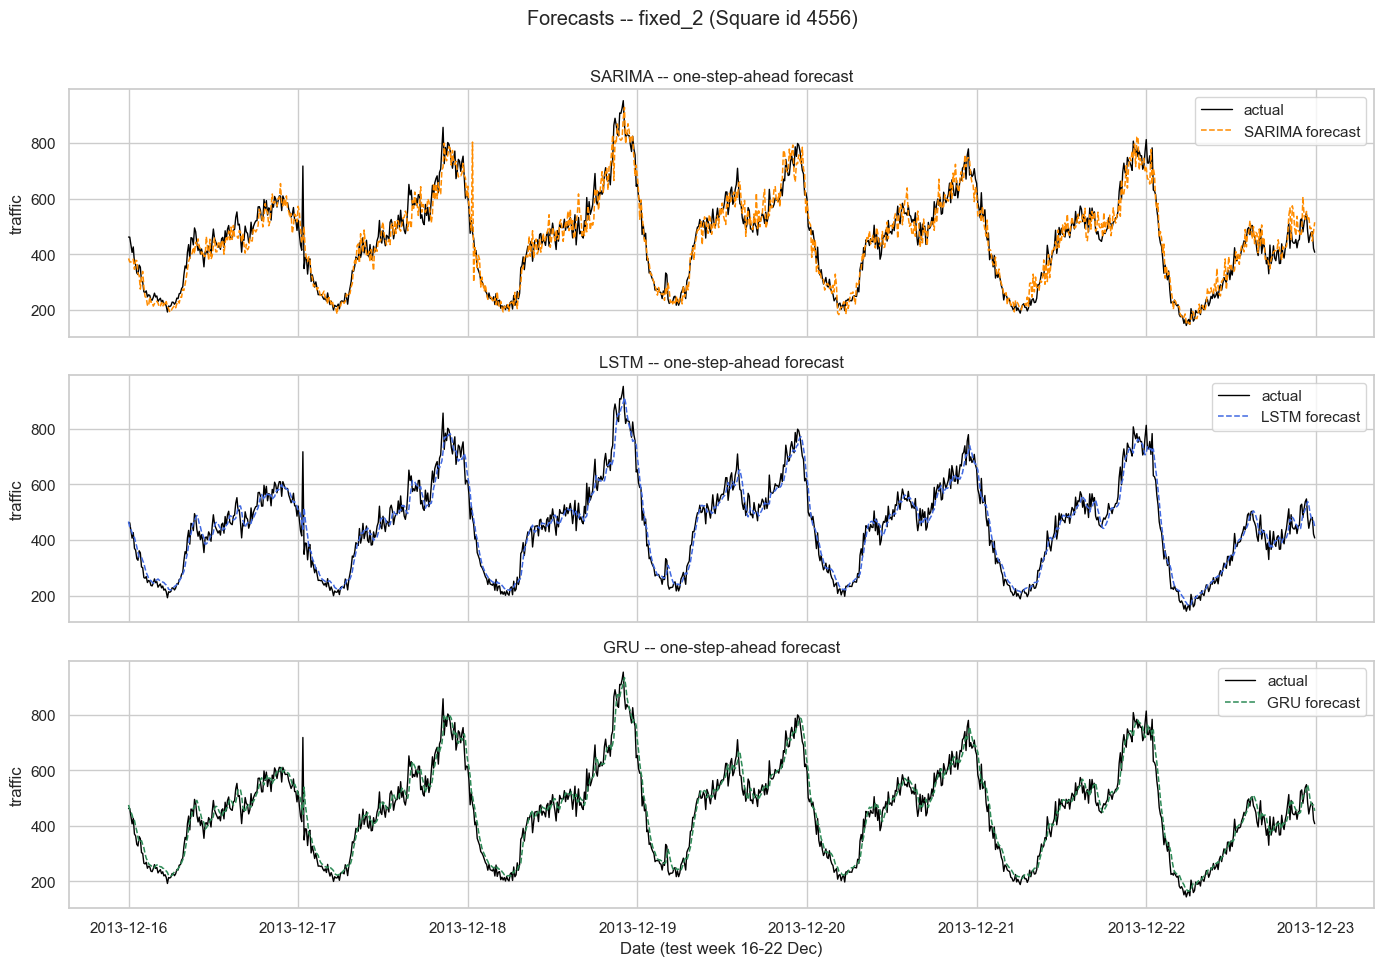

In [8]:
from src.viz import plot_error_over_time
all_results = {}
for label, sid in areas.items():
    s = get_area_series(matrix, sid)
    d = prepare_forecasting_data(s)
    rs = [SarimaForecaster().fit_predict(s),
          NeuralForecaster('LSTM', verbose=0).fit_predict(d),
          NeuralForecaster('GRU', verbose=0).fit_predict(d)]
    all_results[label] = rs
    tbl = metrics_table([evaluate(r.y_true, r.y_pred, r.model_name)
                         for r in rs])
    print(f'\n=== {label} (area {sid}) ===')
    display(tbl)
    display(plot_forecasts_for_area(label, sid, rs))

## 3.IV -- Training & execution time

In [9]:
timing = pd.DataFrame([
    {'area': lab, 'model': r.model_name,
     'train_time_s': r.train_time_s,
     'predict_time_s': r.predict_time_s}
    for lab, rs in all_results.items() for r in rs])
timing.groupby('model')[['train_time_s', 'predict_time_s']].mean()

,train_time_s,predict_time_s
model,,
GRU,8.079402,0.198831
LSTM,9.516460,0.180656
SARIMA,1.439177,0.030907


## 3.VIII -- Failure analysis
Plot the absolute error across the test week to locate the period where the models perform worst.

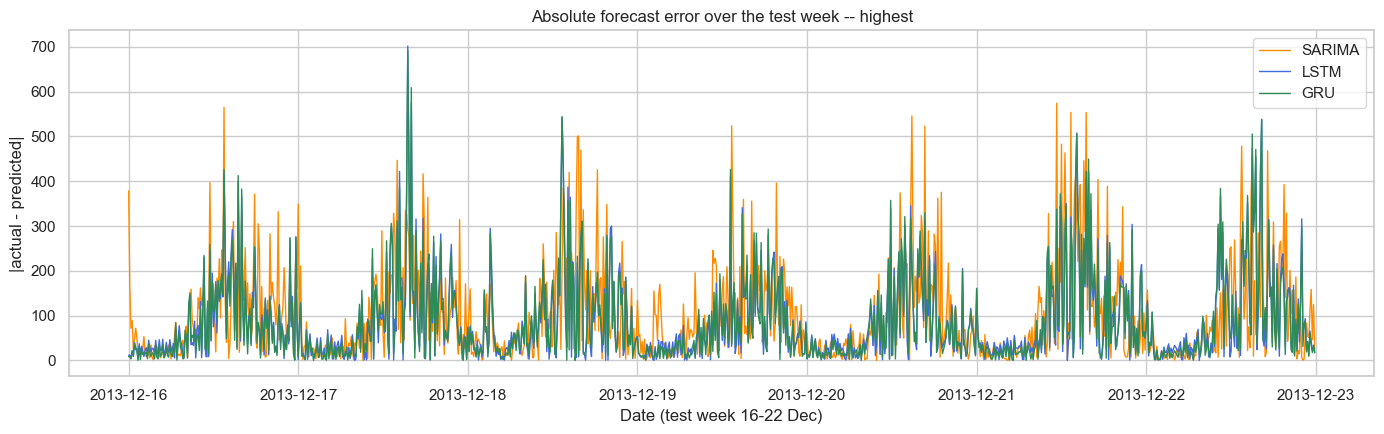

In [10]:
plot_error_over_time('highest', all_results['highest'])

**Failure analysis.** [Identify the worst period -- e.g. an anomalous spike or a public holiday in the test week -- and explain it with reference to the Task 2 anomaly findings.]

## 3.V/3.VII -- Discussion
[Compare predictive accuracy (MAE/RMSE/MAPE), training time and suitability. Justify the best model using both the metrics and the data characteristics from Task 2. Note margins for improvement: calendar features, multi-area input, attention, etc.]

### Optional -- hyper-parameter experiments

In [11]:
# from src.models.experiment import run_neural_experiments
# run_neural_experiments(series, cell='LSTM')   # grid search